In [47]:
import importlib
from IPython.display import display

try:
    import helpers.preprocess as prep
    import helpers.solver as solv
    import helpers.output_writer as ow

    importlib.reload(prep)
    importlib.reload(solv)
    importlib.reload(ow)

    from helpers.preprocess import preprocess_model
    from helpers.solver import solve_complete_model
    from helpers.output_writer import write_run_outputs
except ImportError:
    import preprocess as prep
    import solver as solv
    import output_writer as ow

    importlib.reload(prep)
    importlib.reload(solv)
    importlib.reload(ow)

    from preprocess import preprocess_model
    from solver import solve_complete_model
    from output_writer import write_run_outputs

model_path = "inputs/validation/Validation files from previous examples/verification_uniform_temperature_frame.json"

_, clean_model, data, summary = preprocess_model(model_path)
package = solve_complete_model(clean_model, data)

output_dir, tables, global_summary, dof_summary = write_run_outputs(
    clean_model=clean_model,
    data=data,
    summary=summary,
    package=package,
    model_path=model_path,
    output_root="outputs/runs"
)

print(f"Outputs saved to {output_dir}")
print()

display(tables["model_summary"])
display(tables["node_displacements"])
display(tables["support_reactions"])
display(tables["element_local_end_forces"])
display(tables["element_derived_results"])

Outputs saved to outputs\runs\verification_uniform_temperature_frame



,model_name,length_unit,force_unit,n_nodes,n_elements,n_truss_elements,n_frame_elements,n_free_dofs,n_restrained_dofs,max_displacement_node,max_displacement_magnitude
0,verification_uniform_temperature_frame,m,kN,3,2,0,2,4,14,2,0.000766


,node_id,x,y,z,ux,uy,uz,rx,ry,rz,disp_mag,rot_mag
0,1,0.0,0.0,0.0,0.000000,0.0000,0.0,0.0,0.0,0.000000,0.000000,0.000000
1,2,0.0,10.0,0.0,0.000475,0.0006,0.0,0.0,0.0,0.025356,0.000766,0.025356
2,3,8.0,10.0,0.0,0.000000,0.0000,0.0,0.0,0.0,0.020993,0.000000,0.020993


,node_id,x,y,z,Rx,Ry,Rz,Mx,My,Mz,reaction_force_mag,reaction_moment_mag
0,1,0.0,0.0,0.0,-126.780047,56.855238,0.0,0.0,0.0,222.642377,138.944948,222.642377
1,2,0.0,10.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000
2,3,8.0,10.0,0.0,-113.219953,18.144762,0.0,0.0,0.0,0.000000,114.664685,0.000000


,elem_id,type,node_i,node_j,Fx_i_local,Fy_i_local,Fz_i_local,Mx_i_local,My_i_local,Mz_i_local,Fx_j_local,Fy_j_local,Fz_j_local,Mx_j_local,My_j_local,Mz_j_local
0,1,3D_frame,1,2,56.855238,126.780047,0.0,0.0,0.0,222.642377,-56.855238,113.219953,0.0,0.0,0.0,-154.841903
1,2,3D_frame,2,3,113.219953,56.855238,0.0,0.0,0.0,154.841903,-113.219953,18.144762,0.0,0.0,0.0,0.000000


,elem_id,type,node_i,node_j,L,axial_i_local,axial_j_local,axial_abs_max,shear_y_abs_max,shear_z_abs_max,torsion_abs_max,moment_y_abs_max,moment_z_abs_max,moment_abs_max,stress_axial_i,stress_axial_j,stress_axial_abs_max
0,1,3D_frame,1,2,10.0,56.855238,-56.855238,56.855238,126.780047,0.0,0.0,0.0,222.642377,222.642377,11994.775930,-11994.775930,11994.775930
1,2,3D_frame,2,3,8.0,113.219953,-113.219953,113.219953,56.855238,0.0,0.0,0.0,154.841903,154.841903,23886.065948,-23886.065948,23886.065948


In [48]:
import pandas as pd

df_nodes = tables["node_displacements"].copy()

df_disp_key = df_nodes[df_nodes["node_id"].isin([2, 3])][
    ["node_id", "ux", "uy", "rz", "disp_mag", "rot_mag"]
].sort_values("node_id").reset_index(drop=True)

display(df_disp_key)

,node_id,ux,uy,rz,disp_mag,rot_mag
0,2,0.000475,0.0006,0.025356,0.000766,0.025356
1,3,0.000000,0.0000,0.020993,0.000000,0.020993


In [49]:
df_react = tables["support_reactions"].copy()

df_react_key = df_react[df_react["node_id"].isin([1, 3])][
    ["node_id", "Rx", "Ry", "Rz", "Mx", "My", "Mz"]
].sort_values("node_id").reset_index(drop=True)

display(df_react_key)

,node_id,Rx,Ry,Rz,Mx,My,Mz
0,1,-126.780047,56.855238,0.0,0.0,0.0,222.642377
1,3,-113.219953,18.144762,0.0,0.0,0.0,0.000000


In [50]:
df_local = tables["element_local_end_forces"].copy()

df_local_key = df_local[df_local["elem_id"].isin([1, 2])][
    [
        "elem_id",
        "Fx_i_local", "Fy_i_local", "Fz_i_local",
        "Mx_i_local", "My_i_local", "Mz_i_local",
        "Fx_j_local", "Fy_j_local", "Fz_j_local",
        "Mx_j_local", "My_j_local", "Mz_j_local"
    ]
].sort_values("elem_id").reset_index(drop=True)

display(df_local_key)

,elem_id,Fx_i_local,Fy_i_local,Fz_i_local,Mx_i_local,My_i_local,Mz_i_local,Fx_j_local,Fy_j_local,Fz_j_local,Mx_j_local,My_j_local,Mz_j_local
0,1,56.855238,126.780047,0.0,0.0,0.0,222.642377,-56.855238,113.219953,0.0,0.0,0.0,-154.841903
1,2,113.219953,56.855238,0.0,0.0,0.0,154.841903,-113.219953,18.144762,0.0,0.0,0.0,0.000000


In [51]:
benchmark_rows = [
    {"quantity": "Node 2 ux", "benchmark":  0.00047544, "code": float(df_disp_key.loc[df_disp_key["node_id"] == 2, "ux"].iloc[0])},
    {"quantity": "Node 2 uy", "benchmark":  0.00060026, "code": float(df_disp_key.loc[df_disp_key["node_id"] == 2, "uy"].iloc[0])},
    {"quantity": "Node 2 rz", "benchmark":  0.02535554, "code": float(df_disp_key.loc[df_disp_key["node_id"] == 2, "rz"].iloc[0])},
    {"quantity": "Node 3 rz", "benchmark":  0.02099346, "code": float(df_disp_key.loc[df_disp_key["node_id"] == 3, "rz"].iloc[0])},
    {"quantity": "Node 1 Rx", "benchmark": -126.780047, "code": float(df_react_key.loc[df_react_key["node_id"] == 1, "Rx"].iloc[0])},
    {"quantity": "Node 1 Ry", "benchmark":  56.855238, "code": float(df_react_key.loc[df_react_key["node_id"] == 1, "Ry"].iloc[0])},
    {"quantity": "Node 1 Mz", "benchmark": 222.642377, "code": float(df_react_key.loc[df_react_key["node_id"] == 1, "Mz"].iloc[0])},
    {"quantity": "Node 3 Rx", "benchmark": -113.219953, "code": float(df_react_key.loc[df_react_key["node_id"] == 3, "Rx"].iloc[0])},
    {"quantity": "Node 3 Ry", "benchmark":  18.144762, "code": float(df_react_key.loc[df_react_key["node_id"] == 3, "Ry"].iloc[0])},

   
]

df_compare = pd.DataFrame(benchmark_rows)
df_compare["difference"] = df_compare["code"] - df_compare["benchmark"]

def pct_diff(row):
    b = row["benchmark"]
    if abs(b) < 1e-14:
        return None
    return 100.0 * (row["code"] - b) / b

df_compare["percent_difference"] = df_compare.apply(pct_diff, axis=1)
display(df_compare)

,quantity,benchmark,code,difference,percent_difference
0,Node 2 ux,0.000475,0.000475,2.637915e-09,5.548365e-04
1,Node 2 uy,0.000600,0.000600,1.203509e-09,2.004979e-04
2,Node 2 rz,0.025356,0.025356,-1.225576e-10,-4.833564e-07
3,Node 3 rz,0.020993,0.020993,4.869405e-09,2.319486e-05
4,Node 1 Rx,-126.780047,-126.780047,-4.070988e-07,3.211063e-07
5,Node 1 Ry,56.855238,56.855238,-9.263476e-08,-1.629309e-07
6,Node 1 Mz,222.642377,222.642377,3.299093e-07,1.481790e-07
7,Node 3 Rx,-113.219953,-113.219953,4.070988e-07,-3.595645e-07
8,Node 3 Ry,18.144762,18.144762,9.263477e-08,5.105317e-07


In [52]:
benchmark_local_rows = [
    {
        "elem_id": 1,
        "Fx_i_bench":  56.855238,
        "Fy_i_bench": 126.780047,
        "Mz_i_bench": 222.642377,
        "Fx_j_bench": -56.855238,
        "Fy_j_bench": 113.219953,
        "Mz_j_bench": -154.841903,
    },
    {
        "elem_id": 2,
        "Fx_i_bench": 113.219953,
        "Fy_i_bench":  56.855238,
        "Mz_i_bench": 154.841903,
        "Fx_j_bench": -113.219953,
        "Fy_j_bench":  18.144762,
        "Mz_j_bench":   0.0,
    },
]

df_local_bench = pd.DataFrame(benchmark_local_rows)
df_local_compare = df_local_key.merge(df_local_bench, on="elem_id", how="left")

display(df_local_compare)

,elem_id,Fx_i_local,Fy_i_local,Fz_i_local,Mx_i_local,My_i_local,Mz_i_local,Fx_j_local,Fy_j_local,Fz_j_local,Mx_j_local,My_j_local,Mz_j_local,Fx_i_bench,Fy_i_bench,Mz_i_bench,Fx_j_bench,Fy_j_bench,Mz_j_bench
0,1,56.855238,126.780047,0.0,0.0,0.0,222.642377,-56.855238,113.219953,0.0,0.0,0.0,-154.841903,56.855238,126.780047,222.642377,-56.855238,113.219953,-154.841903
1,2,113.219953,56.855238,0.0,0.0,0.0,154.841903,-113.219953,18.144762,0.0,0.0,0.0,0.000000,113.219953,56.855238,154.841903,-113.219953,18.144762,0.000000


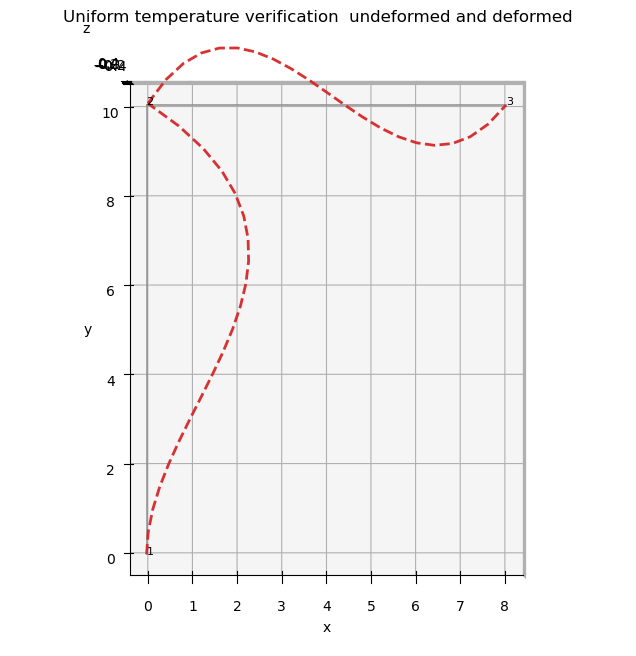

In [53]:
import importlib
import matplotlib.pyplot as plt
from pathlib import Path

try:
    import helpers.plotting_simple as ps
    importlib.reload(ps)
    from helpers.plotting_simple import plot_structure_simple
except ImportError:
    import plotting_simple as ps
    importlib.reload(ps)
    from plotting_simple import plot_structure_simple

fig, ax = plot_structure_simple(
    clean_model,
    data,
    U=package["results"]["U"],
    scale=60.0,
    selector="all",
    show_undeformed=True,
    show_deformed=True,
    show_node_labels=True,
    show_element_labels=False,
    title="Uniform temperature verification  undeformed and deformed",
    view="xy",
    save_path="outputs/validation/simple_plots/verification_uniform_temperature_frame.png",
)

plt.show()

In [54]:
import importlib

try:
    import helpers.plotting_plotly as pp3d
    importlib.reload(pp3d)
    from helpers.plotting_plotly import plot_structure_plotly
except ImportError:
    import plotting_plotly as pp3d
    importlib.reload(pp3d)
    from plotting_plotly import plot_structure_plotly

fig = plot_structure_plotly(
    clean_model,
    data,
    U=package["results"]["U"],
    scale=60.0,
    selector="all",
    show_undeformed=True,
    show_deformed=True,
    show_nodes=True,
    show_node_labels=True,
    show_element_hover=True,
    show_member_loads=True,
    member_load_scale=0.02,
    title="Uniform temperature verification interactive",
    save_html="outputs/validation/plotly_plots/verification_uniform_temperature_frame.html",
    save_png="outputs/validation/plotly_plots/verification_uniform_temperature_frame.png",
)

fig.show()

In [55]:
import importlib
import copy
import numpy as np

try:
    import helpers.elements_3d as e3d
    import helpers.assembly as asm
    import helpers.preprocess as prep

    importlib.reload(e3d)
    importlib.reload(asm)
    importlib.reload(prep)

    from helpers.elements_3d import (
        get_element_fixed_end_force_local,
        get_element_fixed_end_force_global,
    )
    from helpers.assembly import assemble_global_fixed_end_force_vector
    from helpers.preprocess import preprocess_model
except ImportError:
    import elements_3d as e3d
    import assembly as asm
    import preprocess as prep

    importlib.reload(e3d)
    importlib.reload(asm)
    importlib.reload(prep)

    from elements_3d import (
        get_element_fixed_end_force_local,
        get_element_fixed_end_force_global,
    )
    from assembly import assemble_global_fixed_end_force_vector
    from preprocess import preprocess_model

model_path = "inputs/validation/Validation files from previous examples/verification_uniform_temperature_frame.json"

_, clean_model, data, summary = preprocess_model(model_path)

thermal_only_model = copy.deepcopy(clean_model)
thermal_only_model["member_loads"] = []
thermal_only_model["fabrication_errors"] = []
thermal_only_model["nodal_loads"] = []
thermal_only_model["prescribed_displacements"] = []

print("\nTemperature loads in model\n")
print(thermal_only_model["temperature_loads"])

for elem_id in sorted(thermal_only_model["elements"].keys()):
    qf_local = get_element_fixed_end_force_local(thermal_only_model, elem_id)
    qf_global = get_element_fixed_end_force_global(thermal_only_model, elem_id)

    print(f"\nElement {elem_id} thermal qf_local")
    print(np.array2string(qf_local, precision=6, suppress_small=False))

    print(f"\nElement {elem_id} thermal qf_global")
    print(np.array2string(qf_global, precision=6, suppress_small=False))

FEF_global_thermal = assemble_global_fixed_end_force_vector(thermal_only_model, data)

print("\nProject assembled thermal-only FEF_global")
print(np.array2string(FEF_global_thermal, precision=6, suppress_small=False))

# compress 18 DOF 3D vector to 9 DOF in-plane vector
# node 1 -> ux, uy, rz
# node 2 -> ux, uy, rz
# node 3 -> ux, uy, rz
idx = [0, 1, 5, 6, 7, 11, 12, 13, 17]
FEF_inplane = FEF_global_thermal[idx]

print("\nProject assembled thermal-only vector compressed to notebook 2D order")
print(np.array2string(FEF_inplane, precision=6, suppress_small=False))


Temperature loads in model

[{'element': 1, 'deltaT': 10.0}, {'element': 2, 'deltaT': 5.0}]

Element 1 thermal qf_local
[ 113.76    0.      0.      0.      0.      0.   -113.76    0.      0.
    0.      0.      0.  ]

Element 1 thermal qf_global
[   0.    113.76    0.      0.      0.      0.      0.   -113.76    0.
    0.      0.      0.  ]

Element 2 thermal qf_local
[ 56.88   0.     0.     0.     0.     0.   -56.88   0.     0.     0.
   0.     0.  ]

Element 2 thermal qf_global
[ 56.88   0.     0.     0.     0.     0.   -56.88   0.     0.     0.
   0.     0.  ]

Project assembled thermal-only FEF_global
[   0.    113.76    0.      0.      0.      0.     56.88 -113.76    0.
    0.      0.      0.    -56.88    0.      0.      0.      0.      0.  ]

Project assembled thermal-only vector compressed to notebook 2D order
[   0.    113.76    0.     56.88 -113.76    0.    -56.88    0.      0.  ]


In [56]:
import importlib
import copy
import numpy as np
import pandas as pd
from IPython.display import display

try:
    import helpers.preprocess as prep
    import helpers.solver as solv
    import helpers.output_writer as ow
    import helpers.elements_3d as e3d
    import helpers.postprocess as post

    importlib.reload(e3d)
    importlib.reload(prep)
    importlib.reload(post)
    importlib.reload(solv)
    importlib.reload(ow)

    from helpers.preprocess import preprocess_model
    from helpers.solver import solve_complete_model
    from helpers.output_writer import write_run_outputs
except ImportError:
    import preprocess as prep
    import solver as solv
    import output_writer as ow
    import elements_3d as e3d
    import postprocess as post

    importlib.reload(e3d)
    importlib.reload(prep)
    importlib.reload(post)
    importlib.reload(solv)
    importlib.reload(ow)

    from preprocess import preprocess_model
    from solver import solve_complete_model
    from output_writer import write_run_outputs

model_path = "inputs/validation/Validation files from previous examples/verification_uniform_temperature_frame.json"

_, clean_model, data, summary = preprocess_model(model_path)

mech_only_model = copy.deepcopy(clean_model)
mech_only_model["temperature_loads"] = []

package_mech = solve_complete_model(mech_only_model, data)

print("Mechanical-only FEF_global")
print(package_mech["FEF_global"])

print("\nMechanical-only U")
print(package_mech["results"]["U"])

for resp in package_mech["element_responses"]:
    print(f"\nElement {resp['elem_id']} q_local_elem")
    print(resp["q_local_elem"])

Mechanical-only FEF_global
[-120.     0.     0.     0.     0.   200.  -120.    37.5    0.     0.
    0.  -125.     0.    37.5    0.     0.     0.   -75. ]

Mechanical-only U
[ 0.          0.          0.          0.          0.          0.
  0.00095515 -0.00059949  0.          0.          0.          0.02539097
  0.          0.          0.          0.          0.          0.0212007 ]

Element 1 q_local_elem
[  56.83139895  126.81504383    0.            0.            0.
  222.80162984  -56.83139895  113.18495617    0.            0.
    0.         -154.65119157]

Element 2 q_local_elem
[ 113.18495617   56.83139895    0.            0.            0.
  154.65119157 -113.18495617   18.16860105    0.            0.
    0.            0.        ]


In [57]:
package_full = solve_complete_model(clean_model, data)

print("Full combined FEF_global")
print(package_full["FEF_global"])

print("\nFull combined U")
print(package_full["results"]["U"])

for resp in package_full["element_responses"]:
    print(f"\nElement {resp['elem_id']} q_local_elem")
    print(resp["q_local_elem"])

Full combined FEF_global
[-120.    113.76    0.      0.      0.    200.    -63.12  -76.26    0.
    0.      0.   -125.    -56.88   37.5     0.      0.      0.    -75.  ]

Full combined U
[0.         0.         0.         0.         0.         0.
 0.00047544 0.00060026 0.         0.         0.         0.02535554
 0.         0.         0.         0.         0.         0.02099346]

Element 1 q_local_elem
[  56.85523791  126.78004741    0.            0.            0.
  222.64237733  -56.85523791  113.21995259    0.            0.
    0.         -154.84190326]

Element 2 q_local_elem
[ 113.21995259   56.85523791    0.            0.            0.
  154.84190326 -113.21995259   18.14476209    0.            0.
    0.            0.        ]
